# Complete Case Analysis


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [6]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [8]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [9]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
15197,0.920,no_enrollment,High School,3.0,44.0
18373,0.624,Full time course,Graduate,3.0,90.0
18681,0.939,Full time course,Graduate,8.0,68.0
309,0.913,no_enrollment,Graduate,2.0,110.0
8734,0.899,no_enrollment,Graduate,20.0,19.0


In [10]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [11]:
updf = df[cols].dropna()
updf.shape

(17182, 5)

In [12]:
df.shape

(19158, 13)

<Axes: >

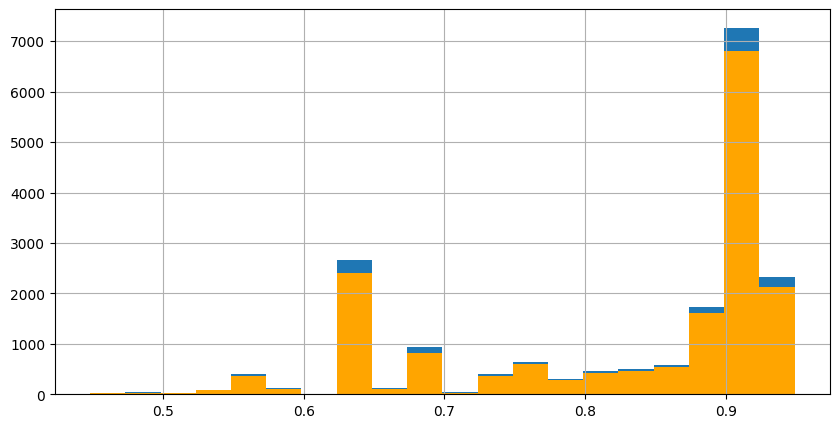

In [14]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=20, ax=ax)

updf['city_development_index'].hist(bins=20, ax=ax,color='orange')

In [15]:
new = pd.concat([df['education_level'].value_counts()/len(df), updf['education_level'].value_counts()/len(updf)], axis=1)

new.columns = ['original', 'updated']   
new

,original,updated
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
